# Assignment 6: Building Your First Neural Network

**Student Name:** [Bailey Allard]

**Date:** [03/14/26]

---

## Assignment Overview

You'll build feedforward neural networks to classify human activities from sensor data. You'll experiment with different architectures, compare performance against Unit 7's PCA+Random Forest approach, and learn when neural networks justify their added complexity.

---

## Step 1: Import Libraries and Load Data

In [1]:
pip install pandas numpy matplotlib seaborn scikit-learn tensorflow

  Obtaining dependency information for tensorflow from https://files.pythonhosted.org/packages/39/59/27adba20bbd1088b00fc0e9232aa21493b4800af2299eb6005017a6053f4/tensorflow-2.21.0-cp312-cp312-macosx_12_0_arm64.whl.metadata
  Obtaining dependency information for absl-py>=1.0.0 from https://files.pythonhosted.org/packages/18/a6/907a406bb7d359e6a63f99c313846d9eec4f7e6f7437809e03aa00fa3074/absl_py-2.4.0-py3-none-any.whl.metadata
  Obtaining dependency information for astunparse>=1.6.0 from https://files.pythonhosted.org/packages/2b/03/13dde6512ad7b4557eb792fbcf0c653af6076b81e5941d36ec61f7ce6028/astunparse-1.6.3-py2.py3-none-any.whl.metadata
  Obtaining dependency information for flatbuffers>=25.9.23 from https://files.pythonhosted.org/packages/e8/2d/d2a548598be01649e2d46231d151a6c56d10b964d94043a335ae56ea2d92/flatbuffers-25.12.19-py2.py3-none-any.whl.metadata
  Obtaining dependency information for gast!=0.5.0,!=0.5.1,!=0.5.2,>=0.2.1 from https://files.pythonhosted.org/packages/1d/33/f1c6a2

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✓ Libraries imported successfully")
print(f"TensorFlow version: {tf.__version__}")

✓ Libraries imported successfully
TensorFlow version: 2.21.0


In [7]:
# Load the Human Activity Recognition dataset
# TODO: Load train.csv and test.csv from the data folder
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")  # Replace with pd.read_csv()

# TODO: Separate features from labels
# The 'Activity' column contains the labels (1-6)
X_train = train_df.drop('Activity', axis=1).values
y_train = train_df['Activity'].values   
X_test = test_df.drop('Activity', axis=1).values
y_test = test_df['Activity'].values

# Encode string labels to integers (0-5)
# Neural networks need numerical labels
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

print("\n" + "="*80)
print("CHECKPOINT: Verify dataset loaded correctly")
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Number of activities: {len(np.unique(y_train))}")
print(f"Activity labels range: {y_train.min()} to {y_train.max()}")
print(f"Activity classes: {label_encoder.classes_}")
print("="*80)


CHECKPOINT: Verify dataset loaded correctly
Training set shape: (7352, 562)
Test set shape: (2947, 562)
Number of features: 562
Number of activities: 6
Activity labels range: 0 to 5
Activity classes: ['LAYING' 'SITTING' 'STANDING' 'WALKING' 'WALKING_DOWNSTAIRS'
 'WALKING_UPSTAIRS']


### Standardize Features

Neural networks learn best when features are normalized to similar scales

In [8]:
# TODO: Use StandardScaler to normalize features
# Fit on training data, transform both train and test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Replace with scaled training data
X_test_scaled = scaler.transform(X_test)   # Replace with scaled test data

print("\n" + "="*80)
print("CHECKPOINT: Features Standardized")
print(f"Mean of scaled features: {X_train_scaled.mean():.6f}")
print(f"Std of scaled features: {X_train_scaled.std():.6f}")
print("="*80)


CHECKPOINT: Features Standardized
Mean of scaled features: 0.000000
Std of scaled features: 1.000000


---
## Step 2: Build and Train Baseline Neural Network

### Create Baseline Architecture (1 Hidden Layer)

In [10]:
# TODO: Build a Sequential model with:
# - Input layer: Dense(64, activation='relu', input_shape=(562,))
# - Output layer: Dense(6, activation='softmax')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

baseline_model = Sequential([
    Dense(64, activation='relu', input_shape=(562,)),
    Dense(6, activation='softmax')
])

# TODO: Compile the model with:
# - optimizer='adam'
# - loss='sparse_categorical_crossentropy'
# - metrics=['accuracy']
baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
if baseline_model is not None:
    baseline_model.summary()
else:
    print("Model not created yet")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        36,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,422 (142.27 KB)

 Trainable params: 36,422 (142.27 KB)

 Non-trainable params: 0 (0.00 B)

### Train Baseline Model

In [11]:
# TODO: Train the model for 20 epochs with validation_split=0.2
# Save the training history and training time

print("Training baseline model (1 hidden layer, 64 nodes)...")
start_time = time.time()

# Your training code here
baseline_history = baseline_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2
)

baseline_time = time.time() - start_time

# TODO: Evaluate on test set
baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(X_test_scaled, y_test)

print("\n" + "="*80)
print("BASELINE MODEL RESULTS")
print("="*80)
print(f"Architecture: 1 hidden layer, 64 nodes")
print(f"Test accuracy: {baseline_test_accuracy if baseline_test_accuracy else 'Not calculated'}")
print(f"Training time: {baseline_time:.2f} seconds")
print("="*80)

Training baseline model (1 hidden layer, 64 nodes)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8815 - loss: 0.3190 - val_accuracy: 0.9354 - val_loss: 0.1623
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9719 - loss: 0.0971 - val_accuracy: 0.9409 - val_loss: 0.1540
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9808 - loss: 0.0646 - val_accuracy: 0.9429 - val_loss: 0.1560
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9845 - loss: 0.0497 - val_accuracy: 0.9388 - val_loss: 0.1631
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9869 - loss: 0.0414 - val_accuracy: 0.9381 - val_loss: 0.1770
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9898 - loss: 0.0352 - val_accuracy: 0.9375 - val_loss: 0.1891
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9905 - loss: 0.0308 - val_accuracy: 0.9402 - val_loss: 0.1969
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/ste

---
## Step 3: Experiment with Network Depth (Number of Layers)

### Shallow Network (1 Layer) - Already Done Above

Baseline model = 1 hidden layer with 64 nodes

### Medium Network (2 Layers)

In [12]:
# TODO: Build model with 2 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(6, activation='softmax')

medium_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

# TODO: Compile with same settings as baseline
medium_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs with validation_split=0.2
print("Training medium network (2 hidden layers)...")
medium_history = medium_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2
)

# TODO: Evaluate on test set
medium_test_loss, medium_test_accuracy = medium_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium network test accuracy: {medium_test_accuracy if medium_test_accuracy else 'Not calculated'}")

Training medium network (2 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8966 - loss: 0.2676 - val_accuracy: 0.9300 - val_loss: 0.1614
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9708 - loss: 0.0852 - val_accuracy: 0.9273 - val_loss: 0.1887
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9735 - loss: 0.0693 - val_accuracy: 0.9245 - val_loss: 0.2234
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9813 - loss: 0.0466 - val_accuracy: 0.9354 - val_loss: 0.2026
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9886 - loss: 0.0347 - val_accuracy: 0.9368 - val_loss: 0.2044
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9913 - loss: 0.0273 - val_accuracy: 0.9320 - val_loss: 0.2275
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9918 - loss: 0.0236 - val_accuracy: 0.9341 - val_loss: 0.2437
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accur

### Deep Network (3 Layers)

In [13]:
# TODO: Build model with 3 hidden layers:
# - Dense(128, activation='relu', input_shape=(562,))
# - Dense(64, activation='relu')
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

deep_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

# TODO: Compile with same settings
deep_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs with validation_split=0.2
print("Training deep network (3 hidden layers)...")
deep_history = deep_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2
)

# TODO: Evaluate on test set
deep_test_loss, deep_test_accuracy = deep_model.evaluate(X_test_scaled, y_test)

print(f"\nDeep network test accuracy: {deep_test_accuracy if deep_test_accuracy else 'Not calculated'}")

Training deep network (3 hidden layers)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8932 - loss: 0.2803 - val_accuracy: 0.9300 - val_loss: 0.1777
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9689 - loss: 0.0899 - val_accuracy: 0.9307 - val_loss: 0.1896
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9767 - loss: 0.0645 - val_accuracy: 0.9279 - val_loss: 0.1960
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9811 - loss: 0.0468 - val_accuracy: 0.9402 - val_loss: 0.1652
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9872 - loss: 0.0351 - val_accuracy: 0.9354 - val_loss: 0.1991
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9898 - loss: 0.0298 - val_accuracy: 0.9327 - val_loss: 0.2188
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9917 - loss: 0.0253 - val_accuracy: 0.9395 - val_loss: 0.2208
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accurac

### Compare Depth Experiments

In [14]:
# TODO: Create comparison of depth experiments
depth_results = pd.DataFrame({
    'Architecture': ['1 Layer (64)', '2 Layers (128, 64)', '3 Layers (128, 64, 32)'],
    'Test Accuracy': [baseline_test_accuracy, medium_test_accuracy, deep_test_accuracy]
})

print("\n" + "="*80)
print("DEPTH EXPERIMENT RESULTS")
print("="*80)
print(depth_results.to_string(index=False))
print("="*80)


DEPTH EXPERIMENT RESULTS
          Architecture  Test Accuracy
          1 Layer (64)       0.927384
    2 Layers (128, 64)       0.931116
3 Layers (128, 64, 32)       0.911775


### Reflection on Network Depth
In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does adding more layers affect performance? 
- At what point do you see diminishing returns?

[By added the second layer we can see that there is a subtle increase to the overall test accuracy to 0.93, but when adding another it dipped back down to 0.91 under the first layers test accuracy score of 0.92. This might suggest that it had the best optimization when only using two layers.]

---
## Step 4: Experiment with Network Width (Nodes Per Layer)

### Narrow Network (2 Layers, 32 Nodes Each)

In [15]:
# TODO: Build model with 2 layers of 32 nodes each
# - Dense(32, activation='relu', input_shape=(562,))
# - Dense(32, activation='relu')
# - Dense(6, activation='softmax')

narrow_model = Sequential([
    Dense(32, activation='relu', input_shape=(562,)),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
narrow_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs
print("Training narrow network (2 layers, 32 nodes each)...")
narrow_history = narrow_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2
)
# TODO: Evaluate
narrow_test_loss, narrow_test_accuracy = narrow_model.evaluate(X_test_scaled, y_test)

print(f"\nNarrow network test accuracy: {narrow_test_accuracy if narrow_test_accuracy else 'Not calculated'}")

Training narrow network (2 layers, 32 nodes each)...
Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8592 - loss: 0.3878 - val_accuracy: 0.9286 - val_loss: 0.1834
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9631 - loss: 0.1110 - val_accuracy: 0.9313 - val_loss: 0.1726
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 973us/step - accuracy: 0.9762 - loss: 0.0730 - val_accuracy: 0.9361 - val_loss: 0.1695
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 980us/step - accuracy: 0.9816 - loss: 0.0547 - val_accuracy: 0.9395 - val_loss: 0.1743
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - accuracy: 0.9838 - loss: 0.0461 - val_accuracy: 0.9375 - val_loss: 0.1919
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.9872 - loss: 0.0389 - val_accuracy: 0.9368 - val_loss: 0.2077
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9893 - loss: 0.0334 - val_accuracy: 0.9361 - val_loss: 0.2195
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.9913 - loss: 0.0291 - val_accuracy: 0.9

### Medium Width Network (2 Layers, 64 Nodes Each)

In [16]:
# TODO: Build model with 2 layers of 64 nodes each
medium_width_model = Sequential([
    Dense(64, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(6, activation='softmax')
])

# TODO: Compile  with the same settings
medium_width_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train for 20 epochs and 64 nodes
print("Training medium-width network (2 layers, 64 nodes each)...")
medium_width_history = medium_width_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2
)

# TODO: Evaluate
medium_width_test_loss, medium_width_test_accuracy = medium_width_model.evaluate(X_test_scaled, y_test)

print(f"\nMedium-width network test accuracy: {medium_width_test_accuracy if medium_width_test_accuracy else 'Not calculated'}")

Training medium-width network (2 layers, 64 nodes each)...
Epoch 1/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8800 - loss: 0.3079 - val_accuracy: 0.9259 - val_loss: 0.2000
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9689 - loss: 0.0930 - val_accuracy: 0.9232 - val_loss: 0.2065
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9796 - loss: 0.0582 - val_accuracy: 0.9266 - val_loss: 0.2053
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9840 - loss: 0.0437 - val_accuracy: 0.9354 - val_loss: 0.1905
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9879 - loss: 0.0349 - val_accuracy: 0.9361 - val_loss: 0.2041
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9898 - loss: 0.0299 - val_accuracy: 0.9327 - val_loss: 0.2299
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9918 - loss: 0.0259 - val_accuracy: 0.9381 - val_loss: 0.2188
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1m

### Wide Network (2 Layers, 128 Nodes Each)

In [17]:
# TODO: Build model with 2 layers of 128 nodes each
wide_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(128, activation='relu'),
    Dense(6, activation='softmax')
])


# TODO: Compile  with the same settings
wide_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train the model
print("Training wide network (2 layers, 128 nodes each)...")
wide_history = wide_model.fit(
    X_train_scaled, y_train,
    epochs=20,
    validation_split=0.2
)

# TODO: Evaluate
wide_test_loss, wide_test_accuracy = wide_model.evaluate(X_test_scaled, y_test)

print(f"\nWide network test accuracy: {wide_test_accuracy if wide_test_accuracy else 'Not calculated'}")

Training wide network (2 layers, 128 nodes each)...
Epoch 1/20


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8895 - loss: 0.2748 - val_accuracy: 0.9239 - val_loss: 0.1636
Epoch 2/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9706 - loss: 0.0845 - val_accuracy: 0.9327 - val_loss: 0.1678
Epoch 3/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9765 - loss: 0.0652 - val_accuracy: 0.9347 - val_loss: 0.1787
Epoch 4/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9830 - loss: 0.0472 - val_accuracy: 0.9388 - val_loss: 0.1745
Epoch 5/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9888 - loss: 0.0344 - val_accuracy: 0.9300 - val_loss: 0.2045
Epoch 6/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9896 - loss: 0.0280 - val_accuracy: 0.9368 - val_loss: 0.2171
Epoch 7/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9937 - loss: 0.0207 - val_accuracy: 0.9368 - val_loss: 0.2502
Epoch 8/20
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9952 - loss: 0.0172 - val_accuracy: 0.9300 - val_

### Compare Width Experiments

In [18]:
# TODO: Create comparison of width experiments
width_results = pd.DataFrame({
    'Architecture': ['2 Layers (32 each)', '2 Layers (64 each)', '2 Layers (128 each)'],
    'Test Accuracy': [narrow_test_accuracy, medium_width_test_accuracy, wide_test_accuracy]
})

print("\n" + "="*80)
print("WIDTH EXPERIMENT RESULTS")
print("="*80)
print(width_results.to_string(index=False))
print("="*80)


WIDTH EXPERIMENT RESULTS
       Architecture  Test Accuracy
 2 Layers (32 each)       0.925008
 2 Layers (64 each)       0.930098
2 Layers (128 each)       0.925348


### Reflection on Network Width

In the Markdown cell below, write 2-3 sentences that answer the following questions: 
- How does increasing nodes per layer affect performance? 
- Is there a point where adding more nodes doesn't help?

[Going from the 2 layer 32 to a 2 layer 64 nodes actually came back with the highest accuracy out of all three of the models. The second highest accuracy was the model with the most nodes 128 which could mean it was overworked.]

---
## Step 5: Train Best Architecture and Visualize Learning

### Identify and Train Best Architecture

In [24]:
# TODO: Based on your experiments above, build your best-performing architecture
# Train it for 30 epochs (longer training often improves performance)

best_model = Sequential([
    Dense(128, activation='relu', input_shape=(562,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(6, activation='softmax')
])

# TODO: Compile the model
best_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training best model for 30 epochs...")
start_time = time.time()

# TODO: Train for 30 epochs with validation_split=0.2
best_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=30,
    validation_split=0.2
)

best_time = time.time() - start_time

# TODO: Evaluate on test set
best_test_loss, best_test_accuracy = best_model.evaluate(X_test_scaled, y_test)

print("\n" + "="*80)
print("BEST MODEL RESULTS")
print("="*80)
print(f"Architecture: [2 Hidden layers: (128, 64)]")  # Replace with your architecture description
print(f"Test accuracy: {best_test_accuracy if best_test_accuracy else 'Not calculated'}")
print(f"Training time: {best_time:.2f} seconds")
print("="*80)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training best model for 30 epochs...
Epoch 1/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8851 - loss: 0.2940 - val_accuracy: 0.9320 - val_loss: 0.1577
Epoch 2/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9697 - loss: 0.0839 - val_accuracy: 0.9279 - val_loss: 0.1846
Epoch 3/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9755 - loss: 0.0728 - val_accuracy: 0.9368 - val_loss: 0.1637
Epoch 4/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9803 - loss: 0.0491 - val_accuracy: 0.9361 - val_loss: 0.1810
Epoch 5/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9871 - loss: 0.0353 - val_accuracy: 0.9381 - val_loss: 0.1829
Epoch 6/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9903 - loss: 0.0281 - val_accuracy: 0.9395 - val_loss: 0.2114
Epoch 7/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9915 - loss: 0.0250 - val_accuracy: 0.9354 - val_loss: 0.2594
Epoch 8/30
184/184 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9

### Visualize Training Progress - Accuracy

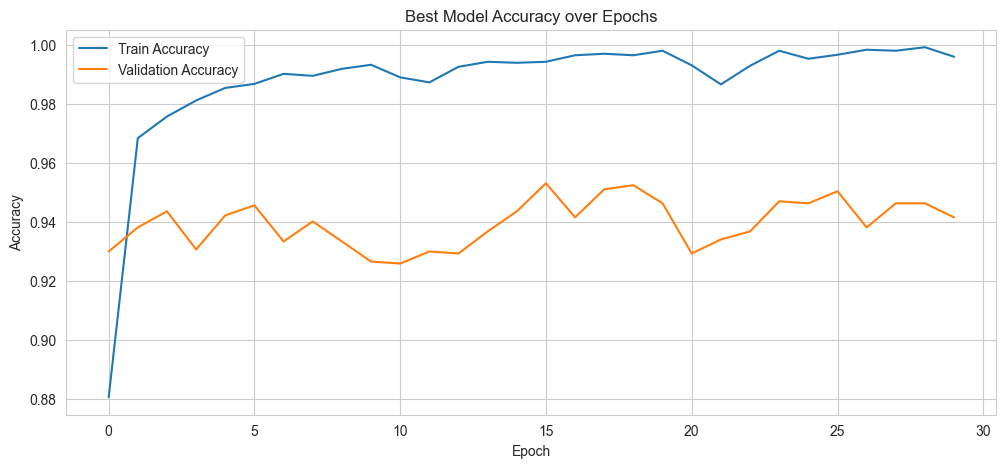

In [20]:
# TODO: Plot training accuracy vs validation accuracy over epochs
# Use best_history.history['accuracy'] and best_history.history['val_accuracy']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Your plotting code here
    plt.plot(best_history.history['accuracy'], label='Train Accuracy')
    plt.plot(best_history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Best Model Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend() 
    plt.show()
else:
    print("Train best model first to visualize results")

### Visualize Training Progress - Loss

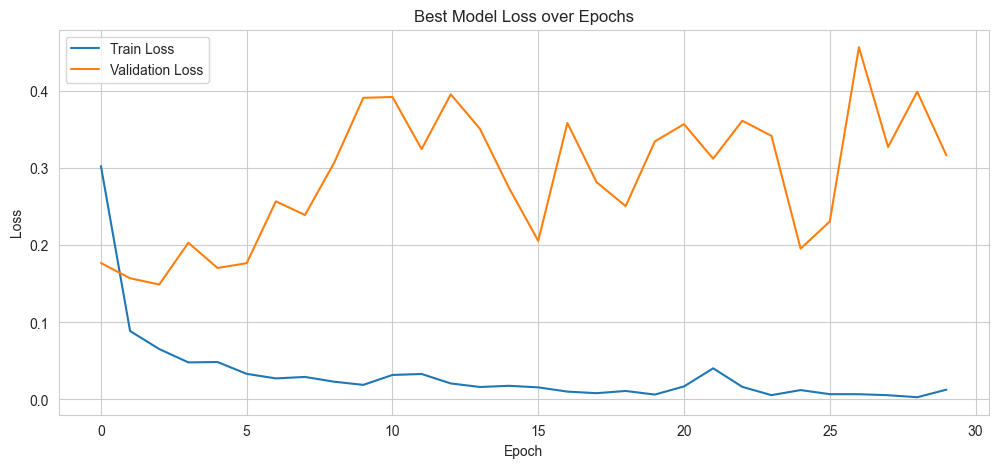

In [21]:
# TODO: Plot training loss vs validation loss over epochs
# Use best_history.history['loss'] and best_history.history['val_loss']

if best_history is not None:
    plt.figure(figsize=(12, 5))
    
    # Your plotting code here
    plt.plot(best_history.history['loss'], label='Train Loss')
    plt.plot(best_history.history['val_loss'], label='Validation Loss')
    plt.title('Best Model Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()
else:
    print("Train best model first to visualize results")

---
## Step 6: Compare Against Unit 7 PCA + Random Forest

In [26]:
# TODO: Enter your Unit 7 PCA+Random Forest results here
# You should have recorded these in Unit 7
unit7_pca_rf_accuracy = 0.861554  # Replace with your Unit 7 test accuracy
unit7_pca_rf_time = 3.685732  # Replace with your Unit 7 training time (if you have it)

# Create comparison table
comparison = pd.DataFrame({
    'Model': [
        'Baseline NN (1 layer, 64 nodes)',
        'Best NN (Your Architecture)',
        'Unit 7: PCA + Random Forest'
    ],
    'Features/Layers': [
        '1 hidden layer',
        '2 hidden layers: (128, 64)',
        '30 PCA components'
    ],
    'Test Accuracy': [
        baseline_test_accuracy,
        best_test_accuracy,
        unit7_pca_rf_accuracy
    ],
    'Training Time': [
        f"{baseline_time:.2f}s" if baseline_time else 'N/A',
        f"{best_time:.2f}s" if best_time else 'N/A',
        f"{unit7_pca_rf_time:.2f}s" if unit7_pca_rf_time else 'N/A'
    ]
})

print("\n" + "="*80)
print("MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7")
print("="*80)
print(comparison.to_string(index=False))
print("="*80)


MODEL COMPARISON: NEURAL NETWORKS VS UNIT 7
                          Model            Features/Layers  Test Accuracy Training Time
Baseline NN (1 layer, 64 nodes)             1 hidden layer       0.927384         5.47s
    Best NN (Your Architecture) 2 hidden layers: (128, 64)       0.918222        10.72s
    Unit 7: PCA + Random Forest          30 PCA components       0.861554         3.69s


### Reflection on Neural Network vs PCA+Random Forest
In the Markdown cell, write 2-3 sentences that answer the following questions:
- How does your best neural network compare to PCA+Random Forest?
- Did the neural network's ability to learn its own features from raw sensor data lead to better performance than manually engineering features with PCA? (2-3 sentences)

[When looking at the neural network and PCA+Random Forest models, I was able to see that in the best base models for neural network even though there was a longer training time it had a the best accuracy out of the two. With that being said when it came to the PCA model it was able to have a faster training time but still had close to the same accuracy the best NN model had which is very interesting.]

---
## Step 7: Reflect on When to Use Neural Networks

### When to Use Neural Networks vs Simpler Models

In the Markdown cell below, write 3-4 sentences addressing the following: 
- Based on your results and what you learned in the resources, when should you use neural networks versus simpler models like random forests? Consider factors like data type (sensor data, images, text vs tabular business data), dataset size, interpretability needs, and performance requirements. 
- Give at least one example of when you'd choose neural networks and one example of when you'd choose random forests

[What I would say to answer some of these questions is that, when you are working with data with a lot of workload or just huges amounts of data, I believe that the Neural networks model would be the best for those daatsets. The reason for this is because when using the random forest model similarily to how we used it in our last assignment you could see less accuracy not to mention there might be information that is not used. I'm not saying the random forest isn't a good fit for big workloads but I believe that its main pro that can be a con as well is the fact that it is easier to interpret and as shown in the model above is a lot fasters for training time. Going back to our last assignment I believe that if were were using NN model for the activities it would be better than the PCA model and an example for when to use the PCA model I would say a good option is for overall store sales and preformance.]

---
## Step 8: Submit Your Work

Before submitting:
1. Make sure all code cells run without errors
2. Verify you have:
   - Baseline neural network trained and evaluated
   - At least 3 depth experiments (1, 2, 3 layers)
   - At least 3 width experiments (32, 64, 128 nodes)
   - Best model trained for 30 epochs with accuracy and loss plots
   - Comparison table with baseline NN, best NN, and Unit 7 PCA+RF
   - All reflection questions answered (2-3 or 3-4 sentences each)
3. Check that all visualizations display correctly

Then push to GitHub:
```bash
git add .
git commit -m 'completed neural networks assignment'
git push
```

Submit your GitHub repository link on the course platform.